<small>Começámos por importar as bibliotecas necessárias para a análise e manipulação de dados.
NumPy é útil para cálculos numéricos e Pandas para manipulação de dados.
Decidimos também ignorar avisos irrelevantes para manter o output limpo.</small>


In [ ]:
import numpy as np
import pandas as pd 
import random as random

# Ignorar avisos irrelevantes
import warnings
warnings.filterwarnings("ignore")

<small>Carregámos o ficheiro CSV com todas os dados de aprovação de empréstimos que serão estudados para um DataFrame do Pandas. Visualizámos as primeiras 5 linhas para conhecer a estrutura inicial do dataset.</small>

In [3]:
df = pd.read_csv("musae_git_edges.csv")
df.head()

,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


In [4]:
df2 = pd.read_csv("musae_git_target.csv")
df2.head()

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


<small>Com o método .shape, verificámos o número total de linhas (instâncias) e colunas (atributos) do dataset.</small>

In [5]:
df.shape

(289003, 2)

In [6]:
df2.shape

(37700, 3)

<small>Verificámos os tipos de dados de cada coluna com .info() e analisámos a presença de valores nulos usando .isnull().sum() .
Esta etapa é essencial para perceber a estrutura interna do dataset, se existem instâncias incompletas e prepará-lo para as próximas fases de limpeza.</small>

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289003 entries, 0 to 289002
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id_1    289003 non-null  int64
 1   id_2    289003 non-null  int64
dtypes: int64(2)
memory usage: 4.4 MB


id_1    0
id_2    0
dtype: int64

In [8]:
df2.info()
df2.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37700 entries, 0 to 37699
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         37700 non-null  int64 
 1   name       37700 non-null  object
 2   ml_target  37700 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 883.7+ KB


id           0
name         0
ml_target    0
dtype: int64

Verificámos se o dataset_git_edges continha autoligações o que não aconteceu. Se houvessem autoligações teriam de ser eliminadas pois este é um grafo simples em que uma pessoa não se pode sequir a si mesma.

In [9]:
autoligacoes = df[df['id_1'] == df['id_2']]

print(f"Número de autoligações encontradas: {len(autoligacoes)}")

Número de autoligações encontradas: 0


Para o dataset_git_edges, organizámos os id's de forma a que os menores apareçam primeiro também entre colunas. Isto é importante já que como as nossas arestas são não direcionadas (1,2) e (2,1) também seriam valores duplicados a limpar. Mesmo assim, o dataset não teve duplicados.

In [10]:
df_sorted = pd.DataFrame(np.sort(df[['id_1', 'id_2']], axis=1), 
                               columns=['id_1', 'id_2'])

In [11]:
df_sorted.duplicated().sum()

0

Para garantir que o dataset musae_git_target também não contém instâncias repetidas, verificámos o número de linhas duplicadas. Como neste caso foi 0 e pudémos proseguir sem ter de fazer alterações.

In [12]:
df2.duplicated().sum()

0

#### Integridade referencial

Filtramos para garantir que todas as arestas em df referem IDs que existem na tabela de nós (df2). Se uma aresta apontar para um ID inexistente, ela deve ser removida para evitar erros nos algoritmos de grafos. No nosso caso todas as arestas tinham correspondencia por isso não foi necessário.

In [13]:
valid_ids = set(df2['id'])

df_filtered = df_sorted[
    df_sorted['id_1'].isin(valid_ids) & 
    df_sorted['id_2'].isin(valid_ids)
]

print(f"Arestas removidas por falta de integridade: {len(df_sorted) - len(df_filtered)}")
print(f"Arestas finais: {df_filtered.shape[0]}")

Arestas removidas por falta de integridade: 0
Arestas finais: 289003


#### Análise da Rede

Criámos o Grafo a partir do DataFrame limpo e verificámos se este é totalmente conexo, o que foi confirmado.

In [14]:
import networkx as nx

G = nx.from_pandas_edgelist(df_filtered, source='id_1', target='id_2')

is_connected = nx.is_connected(G)
print(f"O grafo original é totalmente conexo? {is_connected}")

O grafo original é totalmente conexo? True


#### Sincronizar o Target

Sincronizámos a matriz de adjacência (quem se liga a quem) ao vetor target (quem é desenvolvedor web vs. ML) a partir dos IDs.

In [15]:
nodes_G = list(G.nodes())

df2_final = df2[df2['id'].isin(nodes_G)].reset_index(drop=True)

print("Estrutura do Dataset Final:")
print(f"- Total de Nós: {df2_final.shape[0]}")
print(f"- Total de Arestas: {G.number_of_edges()}")
print(f"- Distribuição de Alvos (ml_target):\n{df2_final['ml_target'].value_counts(normalize=True)}")

Estrutura do Dataset Final:
- Total de Nós: 37700
- Total de Arestas: 289003
- Distribuição de Alvos (ml_target):
ml_target
0    0.741671
1    0.258329
Name: proportion, dtype: float64


metricas de grau

In [42]:
# Grau de cada nó
degree_dict = dict(G.degree())

# Colocar em DataFrame para análise mais simples
deg_df = pd.DataFrame({
    'id': list(degree_dict.keys()),
    'degree': list(degree_dict.values())
})

# Estatísticas descritivas do grau
deg_stats = deg_df['degree'].describe()
print(deg_stats)

count    37700.000000
mean        15.331724
std         80.788102
min          1.000000
25%          2.000000
50%          6.000000
75%         13.000000
max       9458.000000
Name: degree, dtype: float64


O desvio-padrão é muito alto. Isto significa que os graus variam imenso: há muitos developers com poucas ligações e alguns com um número extremamente elevado de ligações.

A conclusão principal é: a rede é muito desigual em termos de grau. A maioria dos developers tem poucas ligações, mas existem alguns developers extremamente conectados, que funcionam como hubs da rede.

Isto também explica porque a média, 15.33, é muito maior do que a mediana, 6. A média está a ser “puxada para cima” por poucos nós com graus muito altos.

In [ ]:
# Distribuição de grau por tipo de developer
deg_df = deg_df.merge(df2_final[['id', 'ml_target']], on='id', how='left')

deg_group_stats = deg_df.groupby('ml_target')['degree'].describe()
print(deg_group_stats)

             count       mean        std  min  25%  50%   75%     max
ml_target                                                            
0          27961.0  17.665391  92.771422  1.0  3.0  6.0  15.0  9458.0
1           9739.0   8.631687  22.253630  1.0  2.0  4.0   9.0   967.0


Em média, têm cerca de 17.67 ligações, mas a mediana continua a ser só 6. Isto mostra que também dentro do grupo Web há muitos developers pouco ligados e poucos developers extremamente conectados.
O valor máximo é 9458, ou seja, o maior hub da rede pertence ao grupo Web.

Em média, têm cerca de 8.63 ligações, e a mediana é 4. Portanto, em geral, os developers ML aparecem menos conectados nesta rede do que os developers Web.
O máximo no grupo ML é 967, muito menor do que o máximo do grupo Web, que era 9458

Estes resultados sugerem que os developers Web estão, em média, mais conectados na rede do que os developers de Machine Learning.
Ou seja, os developers Web parecem ocupar posições mais centrais ou mais conectadas na rede social GitHub analisada.<br>
Isto não significa que todos os Web developers são mais influentes. A maioria continua a ter poucos contactos, mas o grupo Web contém alguns nós extremamente conectados, que aumentam bastante a média.

In [31]:
# Centralidade de grau normalizada
deg_cent = nx.degree_centrality(G)

deg_cent_df = pd.DataFrame({
    'id': list(deg_cent.keys()),
    'deg_centrality': list(deg_cent.values())
})

# Juntar com tipo de developer
deg_cent_df = deg_cent_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)

# Estatísticas por grupo - centralidade de grau
deg_group_stats = deg_cent_df.groupby('ml_target')['deg_centrality'].describe()
print(deg_group_stats)

# Top 10 nós com maior centralidade de grau
top_deg = deg_cent_df.sort_values('deg_centrality', ascending=False).head(10)
print(top_deg[['id', 'deg_centrality', 'ml_target']])


             count      mean       std       min       25%       50%  \
ml_target                                                              
0          27961.0  0.000469  0.002461  0.000027  0.000080  0.000159   
1           9739.0  0.000229  0.000590  0.000027  0.000053  0.000106   

                75%       max  
ml_target                      
0          0.000398  0.250882  
1          0.000239  0.025651  
        id  deg_centrality  ml_target
28   31890        0.250882          0
24   27803        0.187936          0
35   35773        0.088172          0
82   19222        0.078464          0
109  13638        0.065466          0
52   36652        0.062150          0
165  18163        0.051036          0
39    9051        0.047667          0
120  35008        0.041672          0
309  10001        0.041593          0


Os developers Web, ml_target = 0, têm uma centralidade de grau média mais alta do que os developers de Machine Learning, ml_target = 1. <br>
Isto mostra também que o maior hub Web está ligado a cerca de 25% de todos os nós da rede, enquanto o maior hub ML está ligado a cerca de 2.6% dos nós. <br>
E ao ver o top 10 dos nós com maior centralidade vemos que são todos developers web, os que têm mais conexões.

In [ ]:
# Centralidade de proximidade
closeness_cent = nx.closeness_centrality(G)

closeness_cent_df = pd.DataFrame({
    'id': list(closeness_cent.keys()),
    'closeness': list(closeness_cent.values())
})

# Juntar com tipo de developer
closeness_cent_df = closeness_cent_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)

print(closeness_cent_df.head())

# Estatísticas por grupo - centralidade de proximidade
closeness_group_stats = closeness_cent_df.groupby('ml_target')['closeness'].describe()
print(closeness_group_stats)

# Top 10 nós com maior centralidade de proximidade
top_closeness = closeness_cent_df.sort_values('closeness', ascending=False).head(10)
print(top_closeness[['id', 'closeness', 'ml_target']])

# Closeness centrality (amostrada para performance)
#import random
#sample_nodes = random.sample(list(G.nodes()), min(1000, len(G.nodes())))
#closeness_cent = {node: nx.closeness_centrality(G, u=node) for node in sample_nodes}

#closeness_cent_df = pd.DataFrame({
    #'id': list(closeness_cent.keys()),
    #'closeness': list(closeness_cent.values())
#})


      id  closeness  ml_target
0      0   0.275027          0
1  23977   0.379357          0
2      1   0.294980          0
3  34526   0.287230          0
4   2370   0.375365          0
             count      mean       std       min       25%       50%  \
ml_target                                                              
0          27961.0  0.319546  0.039267  0.145151  0.290580  0.318651   
1           9739.0  0.296788  0.040434  0.141389  0.268444  0.290831   

                75%       max  
ml_target                      
0          0.349751  0.523081  
1          0.341750  0.404908  
        id  closeness  ml_target
24   27803   0.523081          0
28   31890   0.517787          0
82   19222   0.466324          0
35   35773   0.450342          0
109  13638   0.447461          0
49   19253   0.447333          0
357  36628   0.442986          0
309  10001   0.442253          0
52   36652   0.439597          0
368  22881   0.431734          0


<Axes: >

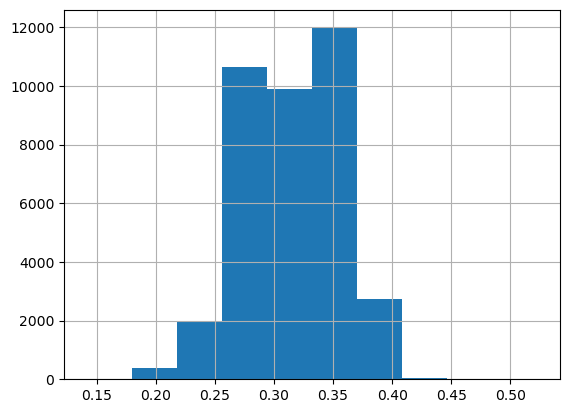

In [46]:
closeness_cent_df['closeness'].hist()

<Axes: title={'center': 'closeness'}, xlabel='ml_target'>

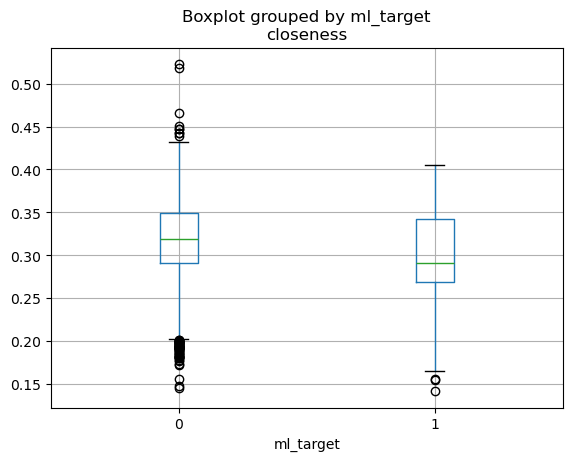

In [47]:
closeness_cent_df.boxplot(column='closeness', by='ml_target')

Os developers Web, além de terem mais ligações diretas, também tendem a estar mais próximos do resto da rede.

In [36]:
# Betweenness centrality
# Usa-se k para amostragem porque o cálculo completo pode ser pesado
bet_cent = nx.betweenness_centrality(G, k=500, seed=42)

bet_cent_df = pd.DataFrame({
    'id': list(bet_cent.keys()),
    'betweenness': list(bet_cent.values())
})

# Juntar com tipo de developer
bet_cent_df = bet_cent_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)

print(bet_cent_df.head())

# Estatísticas por grupo - betweenness
bet_group_stats = bet_cent_df.groupby('ml_target')['betweenness'].describe()
print(bet_group_stats)

# Top 10 nós com maior betweenness
top_bet = bet_cent_df.sort_values('betweenness', ascending=False).head(10)
print(top_bet[['id', 'betweenness', 'ml_target']])


      id   betweenness  ml_target
0      0  0.000000e+00          0
1  23977  7.242102e-05          0
2      1  4.146342e-07          0
3  34526  1.578453e-07          0
4   2370  1.226415e-05          0
             count      mean       std  min           25%           50%  \
ml_target                                                                 
0          27961.0  0.000071  0.002220  0.0  3.916354e-08  1.313037e-06   
1           9739.0  0.000027  0.000204  0.0  0.000000e+00  3.457013e-07   

                75%       max  
ml_target                      
0          0.000014  0.251016  
1          0.000006  0.008302  
        id  betweenness  ml_target
24   27803     0.251016          0
28   31890     0.247964          0
82   19222     0.057817          0
109  13638     0.037892          0
35   35773     0.036187          0
52   36652     0.035138          0
309  10001     0.033007          0
165  18163     0.024894          0
357  36628     0.018522          0
49   19253     0.

Os developers Web têm betweenness média mais alta.

Mas o mais importante é a diferença no valor máximo: Isto mostra que os principais nós intermediários da rede pertencem ao grupo Web.<br>
Ou seja, os developers Web não são apenas mais conectados e mais próximos do resto da rede; alguns também parecem funcionar como pontes estruturais entre diferentes zonas da rede.

In [71]:
# PageRank
pagerank = nx.pagerank(G)

pagerank_df = pd.DataFrame({
    'id': list(pagerank.keys()),
    'pagerank': list(pagerank.values())
})

pagerank_df = pagerank_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)


# Estatísticas por grupo
pagerank_group_stats = pagerank_df.groupby('ml_target')['pagerank'].describe()
print(pagerank_group_stats)

# Top 20 nós com maior PageRank
top_pagerank = pagerank_df.sort_values('pagerank', ascending=False).head(20)
print(top_pagerank[['id', 'pagerank', 'ml_target']])

             count      mean       std       min       25%       50%  \
ml_target                                                              
0          27961.0  0.000029  0.000150  0.000005  0.000008  0.000014   
1           9739.0  0.000018  0.000036  0.000005  0.000007  0.000011   

                75%       max  
ml_target                      
0          0.000026  0.016514  
1          0.000019  0.001420  
        id  pagerank  ml_target
28   31890  0.016514          0
24   27803  0.011451          0
35   35773  0.004919          0
82   19222  0.004669          0
109  13638  0.003875          0
52   36652  0.003799          0
165  18163  0.003381          0
39    9051  0.002722          0
309  10001  0.002665          0
120  35008  0.002338          0
357  36628  0.002276          0
136   5629  0.002273          0
164  33671  0.002255          0
49   19253  0.002109          0
67    2078  0.002061          0
117   7027  0.002051          0
134  11051  0.001884          0
577    

In [ ]:
# Assortatividade de grau
degree_assort = nx.degree_assortativity_coefficient(G)
print("Degree assortativity:", degree_assort)

Degree assortativity: -0.07521713413904481


Como o valor é negativo mas muito perto de 0, o que indica uma fraca tendência desassortativa: nós muito conectados tendem ligeiramente a ligar-se a nós menos conectados. Mas como o efeito é tão baixo pode dizer-se que os nós conectam-se igualmente com nós mais influentes e menos influentes, independentemente da sua própria conectividade.

In [98]:
# Atribuir atributo 'ml_target' aos nós
ml_mapping = dict(zip(df2_final['id'], df2_final['ml_target']))
nx.set_node_attributes(G, ml_mapping, 'ml_target')

# Assortatividade por atributo
attr_assort = nx.attribute_assortativity_coefficient(G, 'ml_target')
print("Attribute assortativity (ml_target):", attr_assort)

Attribute assortativity (ml_target): 0.3778215022223345


Este valor é positivo e moderado o que significa que existe uma tendência para developers do mesmo tipo se ligarem entre si.

Ou seja:
- developers Web tendem a ligar-se mais a developers Web;
- developers ML tendem a ligar-se mais a developers ML;
- há alguma homofilia na rede.

A palavra importante aqui é homofilia: tendência de nós semelhantes se conectarem preferencialmente.

Este resultado é bastante relevante para o vosso projeto, porque mostra que o tipo de developer não está distribuído aleatoriamente na rede. A estrutura das ligações parece refletir parcialmente a categoria profissional dos nós. Isto sugere homofilia moderada: developers do mesmo tipo tendem a ligar-se entre si.

In [ ]:
# Calcular a densidade do grafo
density = nx.density(G)
print(f"Densidade do grafo: {density}")

Densidade do grafo: 0.0004066878203117068


A rede contém apenas cerca de 0.04% das ligações que poderia ter. Esta densidade tão baixa é normal para redes sociais grandes porque cada pessoa está ligada apenas a uma pequena parte do total de utilizadores.

### Número componentes: uma, já que é totalmente conexo

In [54]:
print(nx.number_connected_components(G))
print(len(max(nx.connected_components(G), key=len)))

1
37700


Como já tínhamos visto anteriormente o grafo é totalmente conexo por isso como foi de esperar apenas tem uma componente com tamanho da totalidade dos nós.

### Clustering

In [ ]:
# Coeficiente de clustering por nó
clustering = nx.clustering(G)

clustering_df = pd.DataFrame({
    'id': list(clustering.keys()),
    'clustering': list(clustering.values())
})

# Métricas gerais do clustering
# Coeficiente de clustering médio
avg_clustering = nx.average_clustering(G)
print(f"Coeficiente de clustering médio: {avg_clustering}")

# Transitivity (global clustering)
transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity}")


Average clustering: 0.1675370448010758
Transitivity: 0.012357188884259466


O average clustering obtido foi 0,1675, o que significa que, em média, cerca de 16,75% dos pares de vizinhos de um developer também estão ligados entre si. Este valor indica alguma coesão local na rede: os developers não se ligam de forma totalmente aleatória, existindo círculos ou grupos locais de utilizadores que partilham ligações entre si. No contexto do GitHub, isto pode refletir a existência de pequenos grupos de developers com interesses, comunidades técnicas, linguagens, projetos ou áreas de desenvolvimento semelhantes.

No entanto, este valor não é muito elevado. Assim, embora exista alguma tendência para formação de grupos locais, a rede não é fortemente fechada em pequenos círculos. Isto é coerente com a análise anterior, onde se observou uma rede bastante esparsa, com densidade muito baixa, e com a existência de hubs que ligam muitas partes diferentes da rede.

A transitivity, ou clustering global, foi 0,0124, o que significa que apenas cerca de 1,24% dos trios possíveis estão fechados em triângulos. Este valor é bastante baixo e mostra que, globalmente, a rede tem pouca formação de triângulos. Ou seja, apesar de alguns developers terem vizinhanças localmente coesas, considerando a rede como um todo, a maioria das relações não forma grupos completamente fechados.

A diferença entre o average clustering, 0,1675, e a transitivity, 0,0124, é relevante. O average clustering calcula primeiro o clustering de cada nó e depois faz a média, dando o mesmo peso a developers pouco conectados e muito conectados. Já a transitivity olha para todos os trios da rede de forma global, sendo mais influenciada por nós com grau elevado. Como a rede tem hubs muito fortes, especialmente no grupo Web, muitos trios possíveis envolvem esses hubs, mas os seus vizinhos não estão necessariamente todos ligados entre si. Isso faz com que a transitivity seja muito mais baixa.

Assim, os resultados sugerem uma rede com alguma coesão local, mas fraca coesão global. Existem pequenos círculos de developers interligados, mas a estrutura geral da rede é dominada por muitos nós pouco ligados e alguns hubs que conectam diferentes zonas da rede sem que todos os seus vizinhos estejam ligados entre si.

Portanto, a rede apresenta coesão local moderada-baixa, mas clustering global muito baixo, sendo compatível com uma estrutura esparsa, com hubs e comunidades locais relativamente limitadas.

In [59]:
# Estatísticas descritivas do clustering
print(clustering_df['clustering'].describe())

count    37700.000000
mean         0.167537
std          0.225168
min          0.000000
25%          0.000000
50%          0.100000
75%          0.226316
max          1.000000
Name: clustering, dtype: float64


As estatísticas descritivas do coeficiente de clustering local mostram que a coesão local da rede é bastante desigual. Embora o valor médio seja 0,1675, a mediana é apenas 0,10, o que indica que metade dos developers tem clustering igual ou inferior a 0,10. Além disso, o primeiro quartil é 0, mostrando que pelo menos 25% dos nós não apresentam qualquer ligação entre os seus vizinhos.

O terceiro quartil, 0,2263, indica que 75% dos developers têm clustering local inferior a aproximadamente 0,23, pelo que valores elevados de clustering são relativamente raros. Apesar de o valor máximo ser 1, este resultado deve ser interpretado com cuidado, pois valores máximos podem ocorrer em nós com poucos vizinhos, onde é mais fácil que todos estejam ligados entre si.

Estes resultados reforçam a ideia de que a rede possui alguma coesão local, mas não uma estrutura global fortemente agrupada. Em conjunto com a baixa densidade e a transitivity de 0,0124, conclui-se que a rede é esparsa, apresenta poucos triângulos a nível global e contém apenas alguns círculos locais de developers mais interligados.

In [60]:
# Juntar clustering com tipo de developer
clustering_df = clustering_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)

# Estatísticas de clustering por grupo
clustering_group_stats = clustering_df.groupby('ml_target')['clustering'].describe()

print(clustering_group_stats)

             count      mean       std  min  25%       50%       75%  max
ml_target                                                                
0          27961.0  0.171057  0.217806  0.0  0.0  0.109677  0.233333  1.0
1           9739.0  0.157432  0.244807  0.0  0.0  0.054545  0.200000  1.0


Ao comparar o coeficiente de clustering local por tipo de developer, observa-se que os developers Web apresentam valores ligeiramente superiores aos developers de Machine Learning. O clustering médio dos developers Web é **0,1711**, enquanto o dos developers ML é **0,1574**. A diferença também se verifica na mediana, com **0,1097** para Web e **0,0545** para ML, sugerindo que o developer Web típico está inserido numa vizinhança local um pouco mais coesa.

 Ainda assim, esta diferença não é muito elevada. Em ambos os grupos, o primeiro quartil é **0**, o que indica que pelo menos 25% dos developers, tanto Web como ML, não têm ligações entre os seus vizinhos. Além disso, ambos os grupos apresentam valor máximo de **1**, mostrando que existem casos isolados de vizinhanças totalmente fechadas nos dois tipos de developers.

Estes resultados sugerem que os developers Web não só tendem a ser mais centrais e mais conectados, como também apresentam uma coesão local ligeiramente maior. No entanto, a diferença no clustering é menos marcada do que nas métricas de grau, closeness e betweenness. Assim, a principal distinção entre os grupos parece estar mais relacionada com a centralidade e conectividade global do que com uma diferença muito forte na formação de círculos locais.

In [99]:
# Top 20 nós com maior clustering
top_clustering = clustering_df.sort_values(
    'clustering',
    ascending=False
).head(20)

print(top_clustering[['id', 'clustering', 'ml_target']])


          id  clustering  ml_target
2301   34271         1.0          1
31390  11217         1.0          1
11357   2218         1.0          0
26185   6615         1.0          0
36084  21849         1.0          0
11355  29993         1.0          0
34071  31657         1.0          0
34078  20522         1.0          0
36090  28491         1.0          0
3450   32984         1.0          0
28009  12918         1.0          0
11358  30484         1.0          1
36095  22252         1.0          1
33347  24399         1.0          0
11340  11311         1.0          0
12551  14310         1.0          1
28016   9347         1.0          1
11331  24095         1.0          1
11327  11285         1.0          1
16981  22937         1.0          1


Pode não gignificar muito este top nós já que podem ser casos de nós com muito poucos vizinhos que acabam por só se conectar mutuamente.

### Comunidades

In [64]:
from networkx.algorithms.community import girvan_newman
from itertools import islice
import random

random.seed(42)

sample_nodes = random.sample(list(G.nodes()), 1000)
G_sample = G.subgraph(sample_nodes).copy()

gn_generator = girvan_newman(G_sample)

gn_partitions = list(islice(gn_generator, 3))

for i, communities in enumerate(gn_partitions, start=1):
    communities = tuple(sorted(c) for c in communities)

    print(f"Divisão {i}")
    print(f"Número de comunidades: {len(communities)}")
    print(f"Tamanhos: {[len(c) for c in communities]}")
    print()


Divisão 1
Número de comunidades: 873
Tamanhos: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 3, 1, 2, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 22, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 14, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 18, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 19, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [73]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import modularity
import pandas as pd

# Detetar comunidades com Louvain
communities = louvain_communities(G, seed=42)

print("Número de comunidades:", len(communities))

# Tamanhos das comunidades
community_sizes = [len(c) for c in communities]

print(pd.Series(community_sizes).describe())

# Modularidade
mod_value = modularity(G, communities)
print("Modularidade:", mod_value)

Número de comunidades: 34
count      34.000000
mean     1108.823529
std      2465.090907
min         3.000000
25%         4.250000
50%        10.500000
75%       415.750000
max      8983.000000
dtype: float64
Modularidade: 0.4485177355660237


In [74]:
node_community = {}

for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i

community_df = pd.DataFrame({
    'id': list(node_community.keys()),
    'community': list(node_community.values())
})

print(community_df.head())

      id  community
0  36353          0
1  36359          0
2   3593          0
3   5642          0
4  10764          0


In [75]:
community_df = community_df.merge(
    df2_final[['id', 'ml_target']],
    on='id',
    how='left'
)

print(community_df.head())

      id  community  ml_target
0  36353          0          1
1  36359          0          0
2   3593          0          0
3   5642          0          0
4  10764          0          0


In [77]:
community_composition = (
    community_df
    .groupby(['community', 'ml_target'])
    .size()
    .unstack(fill_value=0)
)

community_composition = community_composition.rename(columns={
    0: 'Web',
    1: 'ML'
})

community_composition['total'] = (
    community_composition.get('Web', 0) + 
    community_composition.get('ML', 0)
)

community_composition['perc_Web'] = community_composition.get('Web', 0) / community_composition['total']
community_composition['perc_ML'] = community_composition.get('ML', 0) / community_composition['total']

community_composition = community_composition.sort_values('total', ascending=False)

print(community_composition.head(10))

ml_target   Web    ML  total  perc_Web   perc_ML
community                                       
22         8452   531   8983  0.940888  0.059112
1          2517  5764   8281  0.303949  0.696051
10         5376  1267   6643  0.809273  0.190727
12         4432   709   5141  0.862089  0.137911
20         3788   403   4191  0.903842  0.096158
7          1209   363   1572  0.769084  0.230916
27         1083   296   1379  0.785352  0.214648
8           434    94    528  0.821970  0.178030
25          339   162    501  0.676647  0.323353
0           113    47    160  0.706250  0.293750


In [78]:
community_composition['purity'] = community_composition[['perc_Web', 'perc_ML']].max(axis=1)

print(community_composition[['total', 'perc_Web', 'perc_ML', 'purity']].head(10))
print("\nEstatísticas da pureza:")
print(community_composition['purity'].describe())

ml_target  total  perc_Web   perc_ML    purity
community                                     
22          8983  0.940888  0.059112  0.940888
1           8281  0.303949  0.696051  0.696051
10          6643  0.809273  0.190727  0.809273
12          5141  0.862089  0.137911  0.862089
20          4191  0.903842  0.096158  0.903842
7           1572  0.769084  0.230916  0.769084
27          1379  0.785352  0.214648  0.785352
8            528  0.821970  0.178030  0.821970
25           501  0.676647  0.323353  0.676647
0            160  0.706250  0.293750  0.706250

Estatísticas da pureza:
count    34.000000
mean      0.838036
std       0.143909
min       0.542857
25%       0.717188
50%       0.815621
75%       1.000000
max       1.000000
Name: purity, dtype: float64


In [89]:
def classify_community(row):
    if row['perc_ML'] >= 0.7:
        return 'ML dominante'
    elif row['perc_Web'] >= 0.7:
        return 'Web dominante'
    else:
        return 'Mista'

community_composition['tipo_comunidade'] = community_composition.apply(classify_community, axis=1)

print(
    community_composition[
        ['total', 'Web', 'ML', 'perc_Web', 'perc_ML', 'purity', 'tipo_comunidade']
    ].head(20)
)

ml_target  total   Web    ML  perc_Web   perc_ML    purity tipo_comunidade
community                                                                 
22          8983  8452   531  0.940888  0.059112  0.940888   Web dominante
1           8281  2517  5764  0.303949  0.696051  0.696051           Mista
10          6643  5376  1267  0.809273  0.190727  0.809273   Web dominante
12          5141  4432   709  0.862089  0.137911  0.862089   Web dominante
20          4191  3788   403  0.903842  0.096158  0.903842   Web dominante
7           1572  1209   363  0.769084  0.230916  0.769084   Web dominante
27          1379  1083   296  0.785352  0.214648  0.785352   Web dominante
8            528   434    94  0.821970  0.178030  0.821970   Web dominante
25           501   339   162  0.676647  0.323353  0.676647           Mista
0            160   113    47  0.706250  0.293750  0.706250   Web dominante
29            79    63    16  0.797468  0.202532  0.797468   Web dominante
18            40     9   

In [90]:
print(community_composition['tipo_comunidade'].value_counts())

tipo_comunidade
Web dominante    24
Mista             8
ML dominante      2
Name: count, dtype: int64


In [91]:
top_communities = community_composition.head(10)

print(top_communities[
    ['total', 'Web', 'ML', 'perc_Web', 'perc_ML', 'purity', 'tipo_comunidade']
])

ml_target  total   Web    ML  perc_Web   perc_ML    purity tipo_comunidade
community                                                                 
22          8983  8452   531  0.940888  0.059112  0.940888   Web dominante
1           8281  2517  5764  0.303949  0.696051  0.696051           Mista
10          6643  5376  1267  0.809273  0.190727  0.809273   Web dominante
12          5141  4432   709  0.862089  0.137911  0.862089   Web dominante
20          4191  3788   403  0.903842  0.096158  0.903842   Web dominante
7           1572  1209   363  0.769084  0.230916  0.769084   Web dominante
27          1379  1083   296  0.785352  0.214648  0.785352   Web dominante
8            528   434    94  0.821970  0.178030  0.821970   Web dominante
25           501   339   162  0.676647  0.323353  0.676647           Mista
0            160   113    47  0.706250  0.293750  0.706250   Web dominante


In [92]:
community_composition.groupby('tipo_comunidade')['total'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_comunidade,,,,,,,,
ML dominante,2.0,23.000000,24.041631,6.0,14.50,23.0,31.50,40.0
Mista,8.0,1107.625000,2903.523472,3.0,5.75,15.0,151.50,8281.0
Web dominante,24.0,1199.708333,2457.996878,3.0,4.00,10.0,740.75,8983.0


<Axes: >

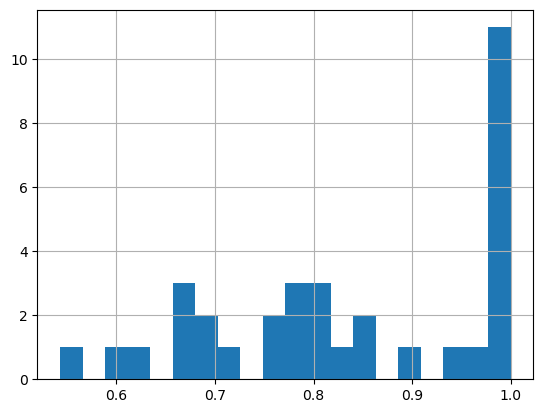

In [93]:
community_composition['purity'].hist(bins=20)

In [96]:
top_purity_communities = community_composition.sort_values(
    'purity',
    ascending=False
).head(360)

print("\nTop 10 comunidades com maior pureza:")
print(
    top_purity_communities[
        ['total', 'Web', 'ML', 'perc_Web', 'perc_ML', 'purity', 'tipo_comunidade']
    ]
)


Top 10 comunidades com maior pureza:
ml_target  total   Web    ML  perc_Web   perc_ML    purity tipo_comunidade
community                                                                 
13             3     3     0  1.000000  0.000000  1.000000   Web dominante
32             3     3     0  1.000000  0.000000  1.000000   Web dominante
11             4     4     0  1.000000  0.000000  1.000000   Web dominante
14             4     4     0  1.000000  0.000000  1.000000   Web dominante
30             3     3     0  1.000000  0.000000  1.000000   Web dominante
2              6     0     6  0.000000  1.000000  1.000000    ML dominante
31             3     3     0  1.000000  0.000000  1.000000   Web dominante
5              6     6     0  1.000000  0.000000  1.000000   Web dominante
15             7     7     0  1.000000  0.000000  1.000000   Web dominante
26            13    13     0  1.000000  0.000000  1.000000   Web dominante
4              3     3     0  1.000000  0.000000  1.000000   W

In [72]:
# Diâmetro aproximado (para grafos grandes)
# Usar amostragem para estimar
sample_nodes_diam = random.sample(list(G.nodes()), min(100, len(G.nodes())))
diameters = []
for node in sample_nodes_diam:
    lengths = nx.single_source_shortest_path_length(G, node)
    if lengths:
        diameters.append(max(lengths.values()))
approx_diameter = max(diameters) if diameters else None
print(f"Diâmetro aproximado: {approx_diameter}")

# Comprimento médio do caminho mais curto (amostrado)
avg_path_lengths = []
for node in sample_nodes_diam:
    lengths = nx.single_source_shortest_path_length(G, node)
    if lengths:
        avg_path_lengths.extend(lengths.values())
approx_avg_path = sum(avg_path_lengths) / len(avg_path_lengths) if avg_path_lengths else None
print(f"Comprimento médio do caminho mais curto aproximado: {approx_avg_path}")

Diâmetro aproximado: 9
Comprimento médio do caminho mais curto aproximado: 3.2887535809018567


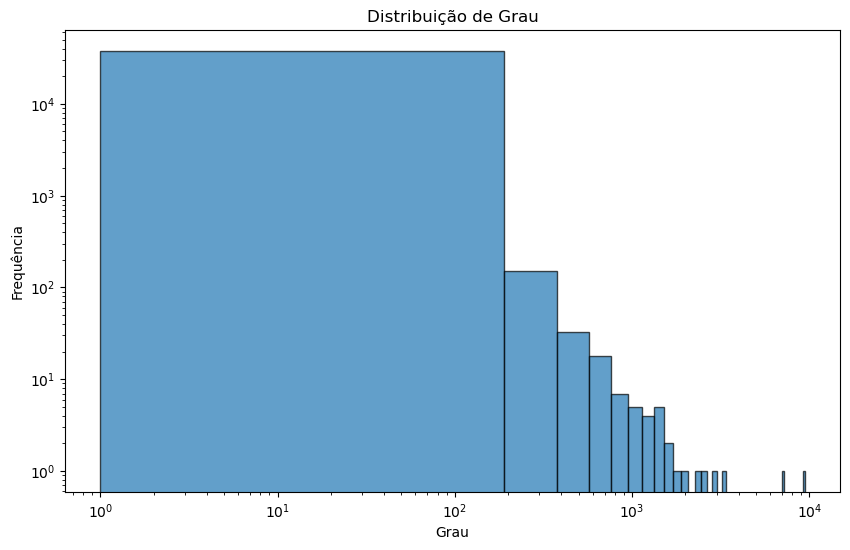

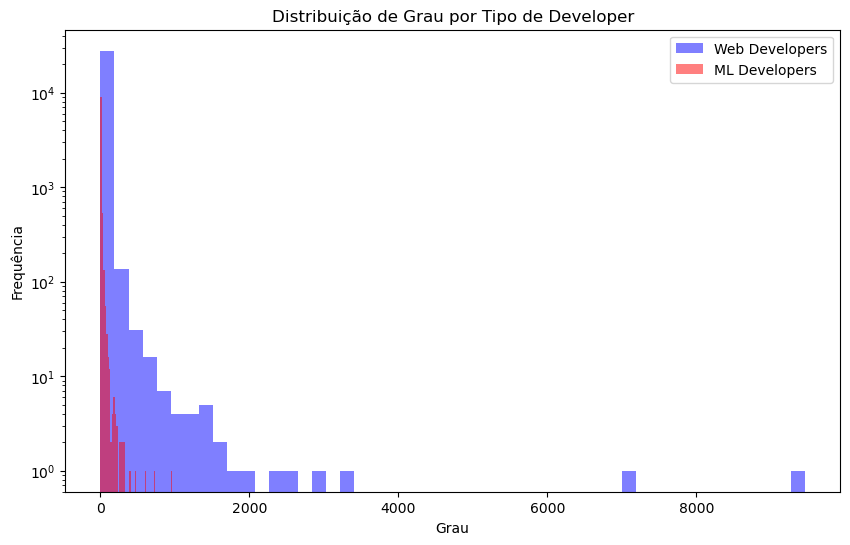

In [ ]:
# Distribuição de grau
import matplotlib.pyplot as plt

degrees = [G.degree(n) for n in G.nodes()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribuição de Grau')
plt.xlabel('Grau')
plt.ylabel('Frequência')
plt.yscale('log')
plt.xscale('log')
plt.show()

# Distribuição por tipo
deg_df_web = deg_df[deg_df['ml_target'] == 0]
deg_df_ml = deg_df[deg_df['ml_target'] == 1]

plt.figure(figsize=(10, 6))
plt.hist(deg_df_web['degree'], bins=50, alpha=0.5, label='Web Developers', color='blue')
plt.hist(deg_df_ml['degree'], bins=50, alpha=0.5, label='ML Developers', color='red')
plt.title('Distribuição de Grau por Tipo de Developer')
plt.xlabel('Grau')
plt.ylabel('Frequência')
plt.legend()
plt.yscale('log')
plt.show()